In [ ]:
# Download e instalação do Quarto
!wget -q https://github.com/quarto-dev/quarto-cli/releases/download/v1.5.57/quarto-1.5.57-linux-amd64.deb
!dpkg -i quarto-1.5.57-linux-amd64.deb

Selecting previously unselected package quarto.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack quarto-1.5.57-linux-amd64.deb ...
Unpacking quarto (1.5.57) ...
Setting up quarto (1.5.57) ...


In [ ]:
# Verificação se o Quarto esta devidamente instalado e atualizado
!quarto --version

1.5.57


# Projeto Final - TNA 5773 - Extração de Conhecimento - Transformando Dados em Conhecimento

### Gabriel C. Guimarães; Karem L. Silva; Keila Miranda-Moraes; Luíza Manso, Matheus Coelho.


AUDITORIA CÍVICA ALGORÍTMICA NA CEAP

## Introdução

A transparência pública no Brasil deixou de ser um preceito meramente burocrático para se consolidar como um requisito central da governança democrática (HUPE; EDWARDS, 2012). Esse movimento, impulsionado por uma demanda social crescente por integridade, coloca a accountability no centro do debate sobre o controle dos recursos coletivos (O’DONNELL, 1998).

Dentro desse cenário, a **Cota para o Exercício da Atividade Parlamentar (CEAP)** surge como um objeto de estudo crítico. Instituída pelo *Ato da Mesa n. 43, de 21 de maio de 2009* da Câmara dos Deputados (BRASIL, 2009), a CEAP é uma verba indenizatória destinada a custear despesas vinculadas ao mandato, como passagens aéreas, alimentação e consultorias, com limite anual não cumulativo para o ano seguinte, mas cumulativo ao longo dos meses do exercício parlamentar. Essa estrutura cumulativa mensal desperta interesse por possibilitar padrões aparentemente normais em análises isoladas, mas potencialmente sugestivos de atipicidades quando observados em escala agregada. No entanto, preveem-se exceções para cargos de liderança e ações especiais, que concedem cota adicional de até 25% cujos repasses, ainda que regulamentados, exigem verificação precisa de conformidade.

O desafio, referente a fiscalização tradicional, baseada em conferência humana, tornou-se inviável diante do volume e da granularidade desses registros. É nesse vácuo que o processo de *Knowledge Discovery in Databases (KDD*) se mostra indispensável, oferecendo o rigor necessário para transformar grandes bases de dados administrativos em conhecimento acionável (FAYYAD; PIATETSKY-SHAPIRO; SMYTH, 1996).

Iniciativas como a Operação Serenata de Amor (OKFN BRASIL, 2017; SERENATA DE AMOR PROJECT, 2017; DAL POZZO, 2020; COSTA JUNIOR, 2024) demonstraram o potencial do uso de inteligência artificial para qualificar o controle social, mas também revelaram um ponto cego analítico, a saber, os microdesvios (*contextual anomalies*) (CHANDOLA; BANERJEE; KUMAR, 2009; AGGARWAL, 2017; PINHEIRO et al., 2017). Esses padrões, que isoladamente se assemelham a comportamentos lícitos, tornam‑se atípicos pela frequência, dispersão ou inadequação ao contexto, como gastos sistematicamente próximos ao limite mensal ou repasses precisos em situações de liderança. A própria natureza dos dados públicos acrescenta complexidade ao problema: registros inconsistentes, falta de padronização entre bases e ausência de rótulos prévios de fraude exigem processos rigorosos de limpeza, normalização e cruzamento de bases, especialmente quando se pretende verificar a ubiquidade espaço‑temporal de parlamentares.

Considerando esse cenário, este estudo investiga a eficácia de modelos computacionais na identificação de gastos que sinalizam ineficiência ou atipicidade, utilizando dados de despesas e participação em eventos legislativos referentes ao período de 2019 a 2025. A investigação se concentra na seguinte questão central: é possível isolar assinaturas comportamentais anômalas e detectar indícios de microdesvios no uso da CEAP por meio de engenharia de variáveis e algoritmos não supervisionados?

Nesse contexto, torna-se necessário recorrer a métodos capazes de identificar padrões atípicos em ambientes sem rótulos prévios de fraude, nos quais irregularidades se manifestam de modo sutil e dependente do contexto situacional. Esta pesquisa articula *flags* heurísticas regras analíticas que sinalizam potenciais irregularidades, como gastos recorrentes no limite mensal ou concentração incomum em fornecedores específicos com técnicas algorítmicas de detecção de anomalias. Entre estas, destaca-se o *IsolationForest* (LIU; TING; ZHOU, 2008), modelo não supervisionado que particiona aleatoriamente o espaço de atributos para isolar observações discrepantes do comportamento majoritário. Como instâncias anômalas tendem a ser isoladas por caminhos mais curtos nas árvores de decisão, o algoritmo atribui pontuações de anomalia com base no comprimento médio desses percursos. A complementaridade entre *Flags* heurísticas explicáveis e aprendizagem de máquina amplia a sensibilidade analítica do processo, permitindo identificar tanto desvios evidentes quanto microdesvios que escapam aos filtros estatísticos tradicionais compondo, assim, a base metodológica para sustentar essa proposta desta investigação.

O objetivo é implementar um ciclo reprodutível de KDD, fundamentado em programação letrada, capaz de extrair conhecimento sobre o comportamento fiscal no Legislativo e oferecer novas ferramentas tecnicamente qualificadas para o controle social no Brasil.





#Metodologia
Em alinhamento com o objetivo da pesquisa, a metodologia explicada a seguir visa estudar se é possível, a partir dos dados públicos disponíveis no site da Câmara dos Deputados, identificar **padrões atípicos e indícios de comportamentos anômalos** em relação ao gasto anual realizado por deputados federais durante o período de **2019 a 2025**.
A partir desses dados, foi feito um processo de sanitização seguido pela limpeza e higienização dos dados. Isso é necessário porque, em sua maioria, dados públicos não tratados trazem informações incorretas ou células sem conteúdo, o que prejudica a análise pelo modelo.

Em seguida, são inseridos os valores da Cota para o Exercício da Atividade Parlamentar (CEAP)(BRASIL, 2009). Nesse documento, além do valor do teto parlamentar, Também são realizadas as etapas de engenharia de variáveis, a consolidação do vetor de features e, com as informações obtidas nessas duas etapas, a Análise Exploratória dos Dados (EDA).

Depois da EDA, é aplicado o modelo de detecção de anomalias chamado Isolation Forest. Na sequência, é feito um processo de *Density-Based Spatial Clustering of Applications with Noise* (DBSCAN) para identificar grupos de parlamentares com comportamentos similares e sinalizar observações que se afastam do padrão geral.

Para interpretar esses padrões identificados é realizada uma etapa de cálculo do **score composto, que sintetiza indícios algorítmicos de afastamento em relação ao comportamento esperado, e a construção de um ranking dos deputados. Em seguida, ocorre um processo de validação dos *outliers* identificados, avaliando se os padrões apontados pelos dados correspondem a comportamentos atípicos em relação ao limite de gasto anual.

Como citado, utiliza-se a planilha de gastos disponível no site da Câmara dos Deputados. Dentre as 32 categorias presentes no planilha, apenas algumas são necessárias para o projeto, sendo elas: nome do parlamentar, CPF do parlamentar, identificador interno da Câmara para o parlamentar, Unidade Federativa (UF) do estado de origem do parlamentar, sigla do partido ao qual o parlamentar é filiado, número da legislatura, descrição textual da subcota, código da subcota da CEAP, nome do fornecedor que emitiu o documento fiscal, CNPJ ou CPF do fornecedor, valor efetivamente reembolsado ao parlamentar, data de emissão do documento fiscal, mês da despesa e ano da despesa.


##Setup e Instalação
Para realizar as análises mencionadas, foi utilizado o espaço do *Google Colab*, pois ele facilita a reprodutibilidade do código por todos os membros do grupo. Além disso, foram utilizadas diversas bibliotecas que trazem mecanismos e recursos necessários para o desenvolvimento das análises e para a geração de gráficos.

Abaixo segue a tabela descrevendo quais bibliotecas foram utilizadas:
### Utilitários e Coleta de Dados
| Biblioteca / Módulo | Versão mínima | Finalidade no projeto |
|---------------------|---------------|------------------------|
| os                  | Padrão Python | Interação com o sistema operacional (variáveis de ambiente, caminhos) |
| re                  | Padrão Python | Expressões regulares para limpeza de strings e extração de padrões |
| zipfile             | Padrão Python | Descompactação dos arquivos .zip baixados do portal da Câmara |
| io.BytesIO          | Padrão Python | Leitura de arquivos em memória sem gravação em disco intermediário |
| pathlib.Path        | Padrão Python | Criação e manipulação de diretórios de forma multiplataforma |
| unicodedata         | Padrão Python | Normalização de caracteres Unicode para correção de encodings |
| time                | Padrão Python | Controle de intervalos entre requisições à API da Câmara |
| requests            | ≥ 2.31        | Download dos arquivos CSV e consultas à API REST da Câmara dos Deputados |

---

## Manipulação e Armazenamento de Dados
| Biblioteca / Módulo     | Versão mínima        | Finalidade no projeto |
|--------------------------|-----------------------|------------------------|
| numpy                    | ≥ 1.26               | Operações vetoriais, geração de sequências e álgebra linear |
| pandas                   | ≥ 2.1                | Manipulação, limpeza e agregação dos dados tabulares da CEAP |
| pyarrow / fastparquet    | ≥ 14.0 / ≥ 2023      | Serialização dos datasets processados no formato Parquet (eficiência de I/O) |

---

## Visualização
| Biblioteca / Módulo     | Versão mínima | Finalidade no projeto |
|--------------------------|---------------|------------------------|
| matplotlib               | ≥ 3.8         | Geração de histogramas, gráficos de barras, radar e heatmaps estáticos |
| matplotlib.ticker        | ≥ 3.8         | Formatação dos eixos (ex: escala percentual no histograma do teto) |
| matplotlib.cm            | ≥ 3.8         | Paletas de cores contínuas usadas no gráfico radar dos outliers |
| seaborn                  | ≥ 0.13        | Geração do heatmap de gastos por UF e ano |
| plotly.express           | ≥ 5.18        | Gráficos interativos: scatter do Isolation Forest e linha temporal |
| plotly.graph_objects     | ≥ 5.18        | Construção de figuras Plotly com controle fino de traços e layouts |
| kaleido                  | ≥ 0.2         | Exportação dos gráficos Plotly como imagens estáticas (PNG/PDF) |

---

## Aprendizado de Máquina (scikit-learn)
| Biblioteca / Módulo                     | Versão mínima | Finalidade no projeto |
|------------------------------------------|---------------|------------------------|
| sklearn.ensemble.IsolationForest         | ≥ 1.3         | Detecção de anomalias não supervisionada — gera o score de risco principal |
| sklearn.preprocessing.StandardScaler     | ≥ 1.3         | Normalização das features antes da aplicação dos algoritmos |
| sklearn.neighbors.NearestNeighbors       | ≥ 1.3         | Cálculo da distância ao k-ésimo vizinho para calibração do eps do DBSCAN |
| sklearn.cluster.DBSCAN                   | ≥ 1.3         | Clusterização por densidade — identifica grupos e ruído (outliers) |
| sklearn.decomposition.PCA                | ≥ 1.3         | Redução de dimensionalidade para visualização 2D dos clusters DBSCAN |
| sklearn.pipeline.Pipeline                | ≥ 1.3         | Encadeamento de etapas de pré-processamento e modelagem |


In [ ]:
# BLOCO 1 — SETUP E INSTALAÇÃO

!pip install -q pyarrow fastparquet scikit-learn plotly kaleido seaborn

import os, re, zipfile, requests
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import cm
import seaborn as sns
import unicodedata
import plotly.express as px
import plotly.graph_objects as go

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline


# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Diretório de saída (compatível com Colab e Quarto/Jupyter)
Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 40)

print("Setup concluído.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 1.9 MB/s eta 0:00:00
Setup concluído.


##*Download* dos Dados Brutos
Os dados usados para realizar o estudo dos gastos dos deputados federais são extraídos diretamente do Portal de Dados Abertos da Câmara dos Deputados.  Esses arquivos são extraídos em formato *Zone Information Protocol* (ZIP), que contém um *Comma-Separated Values* (CSV) com os registros da Cota para Exercício da Atividade Parlamentar (CEAP). Com esse processo de coleta automatizado, caso sejam adicionados mais dados ao site da Câmara, eles serão incluídos na análise realizada pelo código.

Durante a importação dos arquivos, podem haver problemas na interpretação dos caracteres, ou seja, problemas relacionados ao `UTF-8` com `BOM`. Para corrigir isso, os dados são interpretados primeiramente em `latin-1`, devido ao uso de caracteres brasileiros, e em seguida decodificados como UTF-8. Além disso, para melhorar a tratativa dos dados adiante, foram removidos aspas, espaços e caracteres indesejados resultantes dessa conversão. Após esse processo de sanitização dos dados brutos, os arquivos em CSV dos gastos anuais dos deputados foram armazenados localmente.

### Importando os dfs

Aqui estou puxando os dados direto do site da camara

O arquivo ZIP da Câmara é gravado com UTF-8 + BOM mas a extensão .csv sugere latin-1, o que faz o pandas decodificar o BOM como três caracteres de lixo (ï»¿). O separador ; e as aspas na linha de cabeçalho são padrão do Excel brasileiro ao exportar CSV. Documentar isso na seção de Métodos do relatório IMRAD é exatamente o tipo de transparência que o projeto exige.

In [ ]:
# BLOCO 2 — DOWNLOAD DOS DADOS BRUTOS
# Fonte: Portal de Dados Abertos da Câmara dos Deputados
# Legislatura 56 (2019–2022) + Legislatura 57 (2023–2025)

BASE_URL = "https://www.camara.leg.br/cotas/Ano-{ano}.csv.zip"
ANOS = list(range(2019, 2026))   # 2019–2025

# Corrige nomes de colunas com BOM UTF-8 mal decodificado (ï»¿)
# e aspas literais geradas pelo Excel brasileiro.
# Aplica re-encode latin-1 → utf-8 e remove caracteres indesejados.
def sanitizar_colunas(df: pd.DataFrame) -> pd.DataFrame:
    cols = (
        df.columns
          .str.encode("latin-1", errors="replace")  # re-interpreta bytes originais
          .str.decode("utf-8",   errors="replace")  # decodifica como UTF-8 correto
          .str.replace(r'["\'\s]', '', regex=True)  # remove aspas e espaços
          .str.replace(r'^[\W]+',  '', regex=True)  # remove lixo no início
    )
    df.columns = cols

    # Fallback cirúrgico: se a primeira coluna ainda tiver lixo,
    # força o nome correto pelo índice (não depende do conteúdo)
    if "txNomeParlamentar" not in df.columns:
        cols_list = df.columns.tolist()
        cols_list[0] = "txNomeParlamentar"
        df.columns = cols_list
        print("--> [fallback] Primeira coluna renomeada forçadamente para txNomeParlamentar")

    return df


# Baixa, extrai e salva os CSVs anuais de despesas (CEAP).
# Aplica sanitização antes de salvar para que o cache já fique limpo.
def baixar_ceap(anos: list, destino: str = "data/raw") -> None:
    for ano in anos:
        caminho_csv = Path(destino) / f"ceap_{ano}.csv"

        if caminho_csv.exists():
            print(f"--> [cache] {ano} já existe — pulando download.")
            continue

        url = BASE_URL.format(ano=ano)
        print(f"--> Baixando {ano}...", end=" ", flush=True)

        try:
            resp = requests.get(url, timeout=180)
            resp.raise_for_status()
        except requests.RequestException as e:
            print(f"!!! ERRO no download: {e}")
            continue

        with zipfile.ZipFile(BytesIO(resp.content)) as z:
            nome_interno = [n for n in z.namelist() if n.endswith(".csv")][0]
            with z.open(nome_interno) as f:
                # utf-8-sig remove o BOM antes de interpretar (arquivos novos)
                df = pd.read_csv(f, encoding="utf-8-sig", sep=";",
                                 low_memory=False, on_bad_lines="skip")

        df = sanitizar_colunas(df)

        # Salva já com UTF-8 limpo para o cache ficar correto
        df.to_csv(caminho_csv, index=False, encoding="utf-8")
        print(f"--> ({len(df):,} linhas)")

# Executa o download
baixar_ceap(ANOS)

# Carrega, sanitiza e concatena todos os anos
print("\nCarregando arquivos do cache...")
dfs = []
for ano in ANOS:
    caminho_csv = Path("data/raw") / f"ceap_{ano}.csv"
    if not caminho_csv.exists():
        print(f"! [aviso] Arquivo {ano} não encontrado — pulando.")
        continue

    df_tmp = pd.read_csv(caminho_csv, low_memory=False, encoding="utf-8")
    df_tmp = sanitizar_colunas(df_tmp)   # garante limpeza mesmo em caches antigos
    df_tmp["numAno"] = ano               # coluna de ano explícita e uniforme
    dfs.append(df_tmp)
    print(f"  {ano}: {len(df_tmp):,} linhas carregadas")

ceap_raw = pd.concat(dfs, ignore_index=True)

# Confirmação final
print(f"\nTotal de registros brutos: {len(ceap_raw):,}")
print("\nColunas após sanitização:")
print(ceap_raw.columns.tolist())
print("\nPrimeiras linhas:")
ceap_raw.head()

--> Baixando 2019... --> (289,464 linhas)
--> Baixando 2020... --> (166,786 linhas)
--> Baixando 2021... --> (218,439 linhas)
--> Baixando 2022... --> (209,227 linhas)
--> Baixando 2023... --> (236,772 linhas)
--> Baixando 2024... --> (231,967 linhas)
--> Baixando 2025... --> (207,659 linhas)

Carregando arquivos do cache...
  2019: 289,464 linhas carregadas
  2020: 166,786 linhas carregadas
  2021: 218,439 linhas carregadas
  2022: 209,227 linhas carregadas
  2023: 236,772 linhas carregadas
  2024: 231,967 linhas carregadas
  2025: 207,659 linhas carregadas

Total de registros brutos: 1,560,314

Colunas após sanitização:
['txNomeParlamentar', 'cpf', 'ideCadastro', 'nuCarteiraParlamentar', 'nuLegislatura', 'sgUF', 'sgPartido', 'codLegislatura', 'numSubCota', 'txtDescricao', 'numEspecificacaoSubCota', 'txtDescricaoEspecificacao', 'txtFornecedor', 'txtCNPJCPF', 'txtNumero', 'indTipoDocumento', 'datEmissao', 'vlrDocumento', 'vlrGlosa', 'vlrLiquido', 'numMes', 'numAno', 'numParcela', 'txtP

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,numEspecificacaoSubCota,txtDescricaoEspecificacao,txtFornecedor,txtCNPJCPF,txtNumero,indTipoDocumento,datEmissao,vlrDocumento,vlrGlosa,vlrLiquido,numMes,numAno,numParcela,txtPassageiro,txtTrecho,numLote,numRessarcimento,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento
0,LID.GOV-CD,NaN,NaN,NaN,2015,NaN,NaN,55,13,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,0,NaN,CRISTIANE FERREIRA EPP,037.139.030/0010-8,693,4,2019-01-16T00:00:00,111.30,0.00,111.30,1,2019,0,NaN,NaN,1554246,NaN,NaN,NaN,2812,6738121,https://www.camara.leg.br/cota-parlamentar/not...
1,LID.GOV-CD,NaN,NaN,NaN,2019,NaN,NaN,56,13,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,0,NaN,CRISTIANE FERREIRA EPP,037.139.030/0010-8,716,4,2019-02-04T00:00:00,117.19,0.00,117.19,2,2019,0,NaN,NaN,1570078,NaN,NaN,NaN,2812,6769606,https://www.camara.leg.br/cota-parlamentar/not...
2,LID.GOV-CD,NaN,NaN,NaN,2019,NaN,NaN,56,13,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,0,NaN,CRISTIANE FERREIRA EPP,037.139.030/0010-8,723,4,2019-02-25T00:00:00,120.15,0.00,120.15,2,2019,0,NaN,NaN,1570503,NaN,NaN,NaN,2812,6771099,https://www.camara.leg.br/cota-parlamentar/not...
3,LID.GOV-CD,NaN,NaN,NaN,2019,NaN,NaN,56,13,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,0,NaN,CRISTIANE FERREIRA EPP,037.139.030/0010-8,753,4,2019-03-28T00:00:00,151.18,0.00,151.18,3,2019,0,NaN,NaN,1579375,NaN,NaN,NaN,2812,6793690,https://www.camara.leg.br/cota-parlamentar/not...
4,LID.GOV-CD,NaN,NaN,NaN,2019,NaN,NaN,56,13,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,0,NaN,PANIFICADORA FERREIRA NETO LTDA - EPP,037.139.030/0010-8,791,4,2019-05-07T00:00:00,119.90,0.00,119.90,5,2019,0,NaN,NaN,1590980,NaN,NaN,NaN,2812,6821674,https://www.camara.leg.br/cota-parlamentar/not...


##Limpeza e Higienização
Depois da sanitização, realizou-se a etapa de limpeza e padronização dos dados. Primeiramente, os nomes das colunas foram uniformizados por meio de um mapeamento explícito (por exemplo, a coluna numMes passou a ser nomeada como mes), garantindo a consistência entre os anos e os arquivos estudados. Para complementar, foi feita a conversão adequada dos dados: datas foram transformadas em formato datetime, valores monetários foram normalizados para o padrão numérico decimal e campos categóricos, como as siglas das Unidades Federativas, foram padronizadas em caixa alta.

Em seguida, foram removidos dos dados registros inconsistentes, caso existissem. Esses registros incluem: datas fora do período analisado no estudo, valores negativos, numeração incorreta dos meses e unidades federativas inexistentes.  

Adicionalmente, foram incluídas variáveis derivadas para auxiliar nas análises dos gastos: o número da legislatura e a distinção entre gastos parlamentares individuais e despesas de bancada e lideranças. Por fim, os dados limpos foram separados em dois conjuntos, os gastos individuais e os gastos de bancada e liderança e armazenados para uso nas etapas seguintes.


In [ ]:
# BLOCO 3 — LIMPEZA E HIGIENIZAÇÃO

df = ceap_raw.copy()

# Confirma que a sanitização do Bloco 2 funcionou
print("Colunas recebidas do Bloco 2:")
print(df.columns.tolist())

# Renomear
# Mapeamento construído com os nomes REAIS observados no CSV
RENOMEAR = {
    "txNomeParlamentar"        : "nome_parlamentar",
    "cpf"                      : "cpf",
    "ideCadastro"              : "id_cadastro",
    "nuCarteiraParlamentar"    : "num_carteira",
    "nuLegislatura"            : "ano_legislatura",
    "sgUF"                     : "uf",
    "sgPartido"                : "partido",
    "codLegislatura"           : "legislatura",
    "numSubCota"               : "subcota_cod",
    "txtDescricao"             : "descricao",
    "numEspecificacaoSubCota"  : "subcota_especif_cod",
    "txtDescricaoEspecificacao": "descricao_especif",
    "txtFornecedor"            : "fornecedor",
    "txtCNPJCPF"               : "cnpj_fornecedor",
    "txtNumero"                : "num_documento",
    "indTipoDocumento"         : "tipo_documento",
    "datEmissao"               : "data_emissao",
    "vlrDocumento"             : "vlr_documento",
    "vlrGlosa"                 : "vlr_glosa",
    "vlrLiquido"               : "vlr_liquido",
    "numMes"                   : "mes",
    "numAno"                   : "ano",
    "numParcela"               : "parcela",
    "txtPassageiro"            : "passageiro",
    "txtTrecho"                : "trecho",
    "numLote"                  : "lote",
    "numRessarcimento"         : "num_ressarcimento",
    "datPagamentoRestituicao"  : "data_restituicao",
    "vlrRestituicao"           : "vlr_restituicao",
    "nuDeputadoId"             : "id_deputado",
    "ideDocumento"             : "id_documento",
    "urlDocumento"             : "url_documento",
}

# Aplica apenas as colunas que existem (evita KeyError silencioso)
renomear_existentes = {k: v for k, v in RENOMEAR.items() if k in df.columns}
colunas_nao_mapeadas = [c for c in df.columns if c not in RENOMEAR]

df.rename(columns=renomear_existentes, inplace=True)

print(f"\nColunas renomeadas    : {len(renomear_existentes)}")
print(f"Colunas não mapeadas  : {colunas_nao_mapeadas}")
print(f"Colunas após rename   : {df.columns.tolist()}")

# Verifica colunas imprecindíveis
OBRIGATORIAS = [
    "nome_parlamentar", "cpf", "id_deputado",
    "uf", "partido", "legislatura",
    "descricao", "subcota_cod",
    "fornecedor", "cnpj_fornecedor",
    "vlr_liquido", "data_emissao", "mes", "ano",
]
ausentes = [c for c in OBRIGATORIAS if c not in df.columns]
if ausentes:
    raise ValueError(
        f"\nERRO: Colunas obrigatórias ausentes após rename: {ausentes}\n"
        "Verifique o mapeamento RENOMEAR no topo deste bloco."
    )
print("\nTodas as colunas obrigatórias presentes. ✓")

# Tipos: datas
df["data_emissao"] = pd.to_datetime(df["data_emissao"], errors="coerce")

if "data_restituicao" in df.columns:
    df["data_restituicao"] = pd.to_datetime(df["data_restituicao"], errors="coerce")

# Tipos: valores monetários (vírgula → ponto)
COLUNAS_VALOR = ["vlr_documento", "vlr_glosa", "vlr_liquido", "vlr_restituicao"]
for col in COLUNAS_VALOR:
    if col in df.columns:
        df[col] = (df[col].astype(str)
                          .str.replace(r"\s+", "", regex=True)
                          .str.replace(",", ".", regex=False))
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Tipos: inteiros
for col in ["mes", "ano", "legislatura", "subcota_cod",
            "parcela", "lote", "ano_legislatura"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove registros inválidos — DOCUMENTE TUDO
n_antes = len(df)
log = {}

# Datas impossíveis (antes de 2019 ou no futuro)
mask_data = (df["data_emissao"].dt.year < 2019) | \
            (df["data_emissao"] > pd.Timestamp.today())
log["data_invalida"] = mask_data.sum()

# Valor líquido nulo ou negativo
mask_valor = df["vlr_liquido"].isna() | (df["vlr_liquido"] < 0)
log["valor_invalido"] = mask_valor.sum()

# Mês fora do intervalo 1–12
mask_mes = df["mes"].isna() | ~df["mes"].between(1, 12)
log["mes_invalido"] = mask_mes.sum()

# UF inválida (não é sigla de 2 letras conhecida)
UFS_VALIDAS = {
    "AC","AL","AM","AP","BA","CE","DF","ES","GO","MA",
    "MG","MS","MT","PA","PB","PE","PI","PR","RJ","RN",
    "RO","RR","RS","SC","SE","SP","TO"
}
mask_uf = ~df["uf"].isin(UFS_VALIDAS)
log["uf_invalida"] = mask_uf.sum()

# Aplica todos os filtros de uma vez
mask_invalido = mask_data | mask_valor | mask_mes | mask_uf
df = df[~mask_invalido].copy()

print("\nRegistros removidos por motivo:")
for motivo, qtd in log.items():
    print(f"  {motivo:<22}: {qtd:>8,}")
print(f"  {'TOTAL removido':<22}: {mask_invalido.sum():>8,}")
print(f"\n  Antes : {n_antes:>10,}")
print(f"  Depois: {len(df):>10,}")

# Padronizações textuais
df["nome_parlamentar"] = df["nome_parlamentar"].str.strip().str.upper()
df["fornecedor"]       = df["fornecedor"].str.strip().str.upper()
df["partido"]          = df["partido"].str.strip().str.upper()
df["uf"]               = df["uf"].str.strip().str.upper()

# CNPJ/CPF: mantém apenas dígitos para joins futuros
df["cnpj_limpo"] = (df["cnpj_fornecedor"].astype(str)
                                         .str.replace(r"\D", "", regex=True))
df["eh_pessoa_fisica"] = df["cnpj_limpo"].str.len() == 11  # CPF = 11 dígitos

# Cria label de legislatura
df["periodo"] = np.where(df["legislatura"] == 56,
                         "56ª (2019-2022)",
                         "57ª (2023-atual)")

#  Separa lideranças de parlamentares individuais
#  Linhas sem CPF pessoal (ex: LID.GOV-CD) são gastos
#  de bancadas/lideranças, não de deputados individualmente.
df["eh_lideranca"] = (
    df["cpf"].isna() |
    df["nome_parlamentar"].str.contains(
        r"^LID\.|LIDER|LÍDERES|BANCADA|MINORIA|MAIORIA",
        regex=True, na=False
    )
)

ceap_liderancas = df[df["eh_lideranca"]].copy()
ceap            = df[~df["eh_lideranca"]].copy()

print(f"\nRegistros parlamentares individuais : {len(ceap):>10,}")
print(f"Registros de lideranças/bancadas    : {len(ceap_liderancas):>10,}")

# Salva versão limpa
ceap.to_parquet("data/processed/ceap_limpo.parquet", index=False)
ceap_liderancas.to_parquet("data/processed/ceap_liderancas.parquet", index=False)

print("\nArquivos salvos:")
print("  data/processed/ceap_limpo.parquet")
print("  data/processed/ceap_liderancas.parquet")

def corrigir_encoding(texto: str) -> str:
    """
    Corrige nomes com encoding latin-1 interpretado como UTF-8.
    Ex: 'FÃ¡BIO' → 'FÁBIO'
    """
    try:
        return texto.encode("latin-1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return texto  # já está correto, não mexe

Colunas recebidas do Bloco 2:
['txNomeParlamentar', 'cpf', 'ideCadastro', 'nuCarteiraParlamentar', 'nuLegislatura', 'sgUF', 'sgPartido', 'codLegislatura', 'numSubCota', 'txtDescricao', 'numEspecificacaoSubCota', 'txtDescricaoEspecificacao', 'txtFornecedor', 'txtCNPJCPF', 'txtNumero', 'indTipoDocumento', 'datEmissao', 'vlrDocumento', 'vlrGlosa', 'vlrLiquido', 'numMes', 'numAno', 'numParcela', 'txtPassageiro', 'txtTrecho', 'numLote', 'numRessarcimento', 'datPagamentoRestituicao', 'vlrRestituicao', 'nuDeputadoId', 'ideDocumento', 'urlDocumento']

Colunas renomeadas    : 32
Colunas não mapeadas  : []
Colunas após rename   : ['nome_parlamentar', 'cpf', 'id_cadastro', 'num_carteira', 'ano_legislatura', 'uf', 'partido', 'legislatura', 'subcota_cod', 'descricao', 'subcota_especif_cod', 'descricao_especif', 'fornecedor', 'cnpj_fornecedor', 'num_documento', 'tipo_documento', 'data_emissao', 'vlr_documento', 'vlr_glosa', 'vlr_liquido', 'mes', 'ano', 'parcela', 'passageiro', 'trecho', 'lote', 'num

##Teto da Cota para o Exercício da Atividade Parlamentar por Unidade Federativa
A fim de analisar os gastos dos deputados, os limites anuais oficiais da Cota para o Exercício da Atividade Parlamentar (CEAP), conforme estabelecidos pelo Ato da Mesa n° 43/2009 e atualizado pelo Ato da Mesa n° 270/2023, foram incorporados ao código. Os tetos anuais foram organizados por Unidade Federativa, assim como os adicionais previstos para cargos de liderança.

Em seguida, esses valores foram integrados ao *dataset* dos gastos parlamentares por meio da função merge. Dessa forma, é possível comparar entre o gasto efetivo do parlamentar com o limite indicado pelo teto de seu respectivo estado. Desse modo, é garantido que as análises posteriores irão considerar os limites estabelecidos pela CEAP.


In [ ]:
# BLOCO 4 — TETO DA CEAP POR UF (ANUAL)
# Fonte: Ato da Mesa nº 43, de 21/5/2009, com Anexo atualizado
#        pelo Ato da Mesa nº 270, de 19/1/2023 (vigor: 1/2/2023)
# URL: https://www2.camara.leg.br/legin/int/atomes/2009/
#      atodamesa-43-21-maio-2009-588364-normaatualizada-cd-mesa.html
#
# REGRAS RELEVANTES DO ATO (documentadas para o relatório):
#
# Art. 13 — O saldo NÃO utilizado acumula-se ao longo do
#   exercício financeiro. É VEDADA a acumulação entre exercícios.
#   → teto_anual = teto_mensal × 12 (acumulativo no ano)
#
# Art. 1º §1º — Adicionais mensais para cargos especiais:
#   I  → R$ 1.353,04/mês: Líder de Partido/Bloco/Maioria/Minoria/
#          Governo/Oposição, Vice-Líder de Partido/Bloco,
#          Pres./Vice-Pres. de Comissão Permanente,
#          Representante de partido com < 1% da Câmara
#   II → R$   902,02/mês: Vice-Líder da Maioria/Minoria/
#          Governo/Oposição
#   III→ R$ 5.075,62/mês: Suplente de Secretário da Mesa
#   OBS: cargos concomitantes NÃO acumulam adicional (§2º)
#
# Art. 14 §1º — Líder/Vice-Líder PODE ceder seu adicional
#   à Liderança (cota coletiva da bancada).
#   → gastos em nome da "LID.GOV-CD" etc. vêm desse mecanismo
#   → separados no Bloco 3 como ceap_liderancas

# Valores mensais oficiais (Anexo ao Ato da Mesa nº 270/2023)
TETO_MENSAL_UF = {
    "AC": 50_426.26,
    "AL": 46_737.90,
    "AM": 49_363.92,
    "AP": 49_168.58,
    "BA": 44_804.65,
    "CE": 48_245.57,
    "DF": 36_582.46,
    "ES": 43_217.71,
    "GO": 41_300.86,
    "MA": 47_945.49,
    "MG": 41_886.51,
    "MS": 46_336.64,
    "MT": 45_221.83,
    "PA": 48_021.25,
    "PB": 47_826.36,
    "PE": 47_470.60,
    "PI": 46_765.57,
    "PR": 44_665.66,
    "RJ": 41_553.77,
    "RN": 48_525.79,
    "RO": 49_466.29,
    "RR": 51_406.33,
    "RS": 46_669.70,
    "SC": 45_671.58,
    "SE": 45_933.06,
    "SP": 42_837.33,
    "TO": 45_297.41,
}

# Adicionais mensais por cargo especial (Art. 1º §1º)
ADICIONAL_LIDER        = 1_353.04   # Líder, Vice-Líder partido/bloco, Pres. Comissão
ADICIONAL_VICE_LIDER   =   902.02   # Vice-Líder Maioria/Minoria/Governo/Oposição
ADICIONAL_SUPLENTE_SEC = 5_075.62   # Suplente de Secretário da Mesa

# ── Constrói o DataFrame de tetos ────────────────────────
teto_df = pd.DataFrame([
    {
        "uf":                 uf,
        "teto_mensal":        mensal,
        "teto_anual":         mensal * 12,
        # teto anual se o parlamentar tiver cargo especial tipo I
        "teto_anual_lider":   (mensal + ADICIONAL_LIDER) * 12,
        # teto anual se o parlamentar tiver cargo especial tipo II
        "teto_anual_vice":    (mensal + ADICIONAL_VICE_LIDER) * 12,
    }
    for uf, mensal in TETO_MENSAL_UF.items()
])

# ── Merge com ceap (remove colunas antigas se já existirem) ─
ceap.drop(
    columns=["teto_anual", "teto_mensal_ref", "teto_mensal",
             "teto_anual_lider", "teto_anual_vice"],
    errors="ignore",
    inplace=True
)
ceap = ceap.merge(teto_df, on="uf", how="left")
ceap["teto_mensal_ref"] = ceap["teto_mensal"]   # alias para compatibilidade

# Sanidade
uf_sem_teto = ceap[ceap["teto_anual"].isna()]["uf"].unique()
if len(uf_sem_teto) > 0:
    print(f"⚠️  UFs sem teto mapeado: {uf_sem_teto}")
else:
    print("Todas as UFs com teto mapeado. ✓")

print("\nLimites mensais e anuais por UF (Ato da Mesa nº 270/2023):")
print(
    teto_df[["uf", "teto_mensal", "teto_anual"]]
    .sort_values("teto_mensal")
    .assign(
        teto_mensal=lambda x: x["teto_mensal"].map("R$ {:,.2f}".format),
        teto_anual =lambda x: x["teto_anual" ].map("R$ {:,.2f}".format),
    )
    .to_string(index=False)
)

print(f"\nAdicionais mensais por cargo especial:")
print(f"  Líder/Vice-Líder partido/Pres. Comissão : R$ {ADICIONAL_LIDER:,.2f}/mês")
print(f"  Vice-Líder Maioria/Minoria/Gov/Oposição : R$ {ADICIONAL_VICE_LIDER:,.2f}/mês")
print(f"  Suplente de Secretário da Mesa          : R$ {ADICIONAL_SUPLENTE_SEC:,.2f}/mês")


##Engenharia de Variáveis
Depois disso, criaram-se variáveis derivadas com a função de enriquecer ainda mais o conjunto de dados e permitir análises mais detalhadas sobre o comportamento de gastos dos parlamentares. A primeira variável calculada foi composta pelos indicadores mensais de cada deputado, ou seja, o gasto total, o número de transações e diversidade de fornecedores. Esses dados foram comparados aos limites da CEAP, o que possibilitou o cálculo do gasto acumulado anual, do percentual do teto utilizado e da identificação de eventuais ultrapassagens.

A segunda variável desenvolvida foi o **indicador de anomalia no nível da transação**, que serve para detectar notas fiscais seriadas, gastos próximos ao limite mensal, concentração de despesas em um único fornecedor e possíveis inconsistências geográficas em registros de viagem. Também foi gerada uma variável para despesas de alimentação. Desse modo, essas variáveis permitem identificar **padrões atípicos e possíveis indícios de irregularidade.**


In [ ]:
# BLOCO 5 — ENGENHARIA DE VARIÁVEIS

# Gastos mensais e anuais por parlamentar
mensal = (ceap.groupby(["id_deputado", "nome_parlamentar", "uf",
                        "partido", "legislatura", "ano", "mes"])
              .agg(
                  gasto_mes        = ("vlr_liquido", "sum"),
                  n_transacoes_mes = ("vlr_liquido", "count"),
                  n_fornecedores   = ("cnpj_fornecedor", "nunique"),
              )
              .reset_index())

# Merge com teto
mensal = mensal.merge(teto_df, on="uf", how="left")
mensal["teto_mensal_ref"] = mensal["teto_anual"] / 12

# Acumulado anual e uso relativo ao teto
mensal["gasto_acumulado_ano"] = (
    mensal.sort_values("mes")
          .groupby(["id_deputado", "ano"])["gasto_mes"]
          .cumsum()
)
mensal["pct_teto_acumulado"] = (
    mensal["gasto_acumulado_ano"] / mensal["teto_anual"]
)
# Flag: ultrapassou o teto anual
mensal["ultrapassou_teto"] = mensal["pct_teto_acumulado"] > 1.0

# Features de risco — nível TRANSAÇÃO
ceap["ano_mes"] = ceap["ano"].astype(str) + "-" + ceap["mes"].astype(str).str.zfill(2)

# Nota fiscal seriada (mesmo CNPJ, meses seguidos)
# Ordena por parlamentar, fornecedor e data
ceap_sorted = ceap.sort_values(["id_deputado", "cnpj_limpo", "data_emissao"])

ceap_sorted["num_doc_numerico"] = pd.to_numeric(
    ceap_sorted["id_documento"], errors="coerce"
)
ceap_sorted["nf_seriada"] = (
    ceap_sorted.groupby(["id_deputado", "cnpj_limpo"])["num_doc_numerico"]
               .diff()
               .abs()
               .le(3)                         # diferença ≤ 3 = "série suspeita"
               .fillna(False)
)

# Gasto exato no limite mensal de referência
TOLERANCIA_LIMITE = 0.02   # ± 2% do teto mensal
mensal["gasto_limite_exato"] = (
    (mensal["gasto_mes"] >= mensal["teto_mensal_ref"] * (1 - TOLERANCIA_LIMITE)) &
    (mensal["gasto_mes"] <= mensal["teto_mensal_ref"] * (1 + TOLERANCIA_LIMITE))
)

# Concentração em fornecedor único
conc_fornecedor = (
    ceap.groupby(["id_deputado", "ano", "cnpj_limpo"])["vlr_liquido"]
        .sum()
        .reset_index(name="vlr_fornecedor")
)
total_por_dep_ano = (
    ceap.groupby(["id_deputado", "ano"])["vlr_liquido"]
        .sum()
        .reset_index(name="vlr_total_ano")
)
conc_fornecedor = conc_fornecedor.merge(total_por_dep_ano, on=["id_deputado", "ano"])
conc_fornecedor["pct_fornecedor"] = (
    conc_fornecedor["vlr_fornecedor"] / conc_fornecedor["vlr_total_ano"]
)
# Máxima concentração por parlamentar/ano
max_conc = (conc_fornecedor.groupby(["id_deputado", "ano"])["pct_fornecedor"]
                           .max()
                           .reset_index(name="max_conc_fornecedor"))

# CNPJ recém-criado (proxy — sem base Receita Federal)
# Extrai data de fundação do CNPJ (dígitos 3-6 indicam mês/ano abertura)\
# CNPJ formato XXXXXXXXXX/XXXX-XX — os 8 primeiros dígitos são da matriz.
def extrair_ano_cnpj(cnpj: str) -> float:
    try:
        s = re.sub(r"\D", "", str(cnpj))
        if len(s) != 14:
            return np.nan
        # Dígitos 13-14 do CNPJ não têm ano embutido de forma simples,
        # mas a sequência de registro do CNPJ na Receita Federal cresce com o tempo.
        # Esta é uma heurística; para precisão use a base de empresas (Receita Federal).
        return float("nan")
    except Exception:
        return np.nan

# Impossibilidade geográfica e de tempo (mesmo dia, cidades diferentes)
# Usa txtTrecho para detectar múltiplos estados no mesmo dia
if "trecho" in ceap.columns:
    ceap["uf_trecho"] = ceap["trecho"].str.extract(r"\b([A-Z]{2})\b", expand=False)
    viagem_dia = (
        ceap[ceap["descricao"].str.contains("PASSAGEM|COMBUSTÍVEL|COMBUSTIVEL",
                                             case=False, na=False)]
            .groupby(["id_deputado", "data_emissao"])["uf_trecho"]
            .nunique()
            .reset_index(name="n_ufs_dia")
    )
    viagem_dia["impossibilidade_geo"] = viagem_dia["n_ufs_dia"] >= 2

# Gasto médio em alimentação (subcota 13 = alimentação)
SUBCOTA_ALIMENTACAO = 13
gasto_alim = (
    ceap[ceap["subcota_cod"] == SUBCOTA_ALIMENTACAO]
       .groupby(["id_deputado", "ano"])["vlr_liquido"]
       .agg(["sum", "mean", "count"])
       .reset_index()
       .rename(columns={"sum":   "total_alim",
                        "mean":  "media_alim",
                        "count": "n_refeicoes"})
)

print("Features geradas:")
print("  mensal         :", mensal.shape)
print("  max_conc       :", max_conc.shape)
print("  gasto_alim     :", gasto_alim.shape)

##Vetor de Features Consolidados
Desenvolvidas essas variáveis, elas foram consolidadas em um vetor anual por deputado. Para isso, foram calculados indicadores agregados como gasto total, número de transações, *ticket* médio, diversidade de fornecedores e proporção de despesas com pessoa física. Além de incorporar os limites da CEAP a fim de medir o percentual de uso do teto e eventuais ultrapassagens.

Nesse passo, também foram criadas variáveis de risco para indicar **indícios de anomalias como** presença de notas fiscais seriadas, a concentração de gastos em um único fornecedor, meses com gasto próximo ao limite mensal e o gasto com *ticket* médio. Além disso, foi definida a tolerância de +/- 2% do teto mensal do parlamentar. Por fim, todos esses features foram padronizados e armazenados em um dataset.


In [ ]:
# BLOCO 6 — VETOR DE FEATURES CONSOLIDADO (nível: dep x ano)

# Garante que nf_seriada existe em ceap
# O Bloco 5 cria nf_seriada em ceap_sorted (cópia ordenada)
if "nf_seriada" not in ceap.columns:
    ceap_sorted = ceap.sort_values(
        ["id_deputado", "cnpj_limpo", "data_emissao"]
    ).copy()
    ceap_sorted["num_doc_numerico"] = pd.to_numeric(
        ceap_sorted["id_documento"], errors="coerce"
    )
    ceap_sorted["nf_seriada"] = (
        ceap_sorted.groupby(["id_deputado", "cnpj_limpo"])["num_doc_numerico"]
                   .diff()
                   .abs()
                   .le(3)
                   .fillna(False)
    )
    # Devolve apenas a coluna nova ao ceap usando o índice original
    ceap["nf_seriada"] = ceap_sorted["nf_seriada"]

# Resumo anual base
anual = (
    ceap.groupby(["id_deputado", "nome_parlamentar", "uf",
                  "partido", "legislatura", "ano"])
        .agg(
            gasto_total_ano  = ("vlr_liquido",    "sum"),
            n_transacoes     = ("vlr_liquido",    "count"),
            n_fornecedores   = ("cnpj_fornecedor","nunique"),
            ticket_medio     = ("vlr_liquido",    "mean"),
            ticket_desvio    = ("vlr_liquido",    "std"),
            n_nf_seriadas    = ("nf_seriada",     "sum"),
            n_pf             = ("eh_pessoa_fisica","sum"),
        )
        .reset_index()
)

# Merge com teto por UF
anual = anual.merge(teto_df, on="uf", how="left")
anual["pct_teto_uso"]     = anual["gasto_total_ano"] / anual["teto_anual"]
anual["gasto_acima_teto"] = (anual["pct_teto_uso"] > 1.0).astype(int)

# Merge: concentração de fornecedor único
conc_fornecedor = (
    ceap.groupby(["id_deputado", "ano", "cnpj_limpo"])["vlr_liquido"]
        .sum()
        .reset_index(name="vlr_fornecedor")
)
total_por_dep_ano = (
    ceap.groupby(["id_deputado", "ano"])["vlr_liquido"]
        .sum()
        .reset_index(name="vlr_total_ano")
)
conc_fornecedor = conc_fornecedor.merge(
    total_por_dep_ano, on=["id_deputado", "ano"]
)
conc_fornecedor["pct_fornecedor"] = (
    conc_fornecedor["vlr_fornecedor"] /
    conc_fornecedor["vlr_total_ano"].replace(0, np.nan)
)
max_conc = (
    conc_fornecedor.groupby(["id_deputado", "ano"])["pct_fornecedor"]
                   .max()
                   .reset_index(name="max_conc_fornecedor")
)
anual = anual.merge(max_conc, on=["id_deputado", "ano"], how="left")

# Merge: gastos com alimentação (subcota 13)
SUBCOTA_ALIMENTACAO = 13
gasto_alim = (
    ceap[ceap["subcota_cod"] == SUBCOTA_ALIMENTACAO]
       .groupby(["id_deputado", "ano"])["vlr_liquido"]
       .agg(total_alim="sum", media_alim="mean", n_refeicoes="count")
       .reset_index()
)
anual = anual.merge(gasto_alim, on=["id_deputado", "ano"], how="left")
anual[["total_alim", "media_alim", "n_refeicoes"]] = (
    anual[["total_alim", "media_alim", "n_refeicoes"]].fillna(0)
)

# Merge: meses com gasto exato no limite
# Recalcula mensal aqui para garantir que teto_mensal_ref existe
mensal = (
    ceap.groupby(["id_deputado", "nome_parlamentar", "uf",
                  "partido", "legislatura", "ano", "mes"])
        .agg(
            gasto_mes        = ("vlr_liquido", "sum"),
            n_transacoes_mes = ("vlr_liquido", "count"),
        )
        .reset_index()
)
mensal = mensal.merge(teto_df, on="uf", how="left")
mensal["teto_mensal_ref"] = mensal["teto_anual"] / 12

TOLERANCIA = 0.02   # ± 2% do teto mensal de referência
mensal["gasto_limite_exato"] = (
    (mensal["gasto_mes"] >= mensal["teto_mensal_ref"] * (1 - TOLERANCIA)) &
    (mensal["gasto_mes"] <= mensal["teto_mensal_ref"] * (1 + TOLERANCIA))
)

meses_limite = (
    mensal.groupby(["id_deputado", "ano"])["gasto_limite_exato"]
          .sum()
          .reset_index(name="n_meses_limite_exato")
)
anual = anual.merge(meses_limite, on=["id_deputado", "ano"], how="left")
anual["n_meses_limite_exato"] = anual["n_meses_limite_exato"].fillna(0)

# Features derivadas
# Proporção de notas de pessoa física
anual["pct_pf"] = (
    anual["n_pf"] / anual["n_transacoes"].replace(0, np.nan)
)

# Diversidade de categorias de gasto
diversidade = (
    ceap.groupby(["id_deputado", "ano"])["subcota_cod"]
        .nunique()
        .reset_index(name="n_categorias")
)
anual = anual.merge(diversidade, on=["id_deputado", "ano"], how="left")

# Label de legislatura para análise comparativa
anual["periodo"] = np.where(
    anual["legislatura"] == 56,
    "56ª (2019-2022)",
    "57ª (2023-atual)"
)

# Preenche NaN remanescentes com 0
FEATURES_NUMERICAS = [
    "pct_teto_uso", "gasto_acima_teto", "max_conc_fornecedor",
    "total_alim", "media_alim", "n_refeicoes",
    "n_meses_limite_exato", "pct_pf", "n_categorias",
    "ticket_desvio", "n_nf_seriadas",
]
anual[FEATURES_NUMERICAS] = anual[FEATURES_NUMERICAS].fillna(0)

# Salva e exibe
anual.to_parquet("data/processed/features_anual.parquet", index=False)

print(f"Vetor de features final: {anual.shape}")
print(f"\nColunas disponíveis:\n{anual.columns.tolist()}")
print("\nAmostra:")
print(
    anual[["nome_parlamentar", "uf", "ano", "gasto_total_ano",
           "pct_teto_uso", "max_conc_fornecedor",
           "n_nf_seriadas", "n_meses_limite_exato"]]
    .sort_values("pct_teto_uso", ascending=False)
    .head(20)
    .to_string(index=False)
)

In [ ]:
# Os graficos dos top 10 parlagemtares foi gerado utilizando gasto_total_ano divido por tato_anual, gerando assim a porcentagem gasta
# Get unique years from the 'anual' DataFrame
years = sorted(anual['ano'].unique())

# Define the number of top parliamentarians to display per year
TOP_N_PARLAMENTARIANS = 10

# Generate a plot for each year
for year in years:
    # Filter data for the current year and sort by 'pct_teto_uso'
    df_year = anual[anual['ano'] == year].sort_values(
        'pct_teto_uso', ascending=False
    ).head(TOP_N_PARLAMENTARIANS)

    if not df_year.empty:
        fig = px.bar(
            df_year,
            x='pct_teto_uso',
            y='nome_parlamentar',
            orientation='h',
            title=f'Top {TOP_N_PARLAMENTARIANS} Parliamentarians by CEAP Usage - {year}',
            labels={'pct_teto_uso': 'Percentage of Annual Quota Used', 'nome_parlamentar': 'Parliamentarian Name'},
            template='plotly_white'
        )

        fig.update_layout(
            yaxis={'categoryorder': 'total ascending'},
            xaxis_tickformat=".0%"
        )
        fig.show()
    else:
        print(f"No data available for year {year} to plot.")

##Análise Exploratória dos Dados
Definido esse *dataset*, iniciou-se a etapa da análise exploratória dos dados. Essa etapa tem como característica compreender padrões e potenciais anomalias nos gastos da CEAP a partir de representações gráficas. A primeira delas é um gráfico para avaliar o percentual de gasto do teto anual de cada parlamentar por legislatura, um gráfico que retrata a evolução da mediana mensal dos gastos entre 2019 e 2025, um gráfico que divide os gastos em subcategorias que foram indicadas no arquivo CSV da Câmara e por último a geração de um mapa de calor para analisar os gastos anuais por Unidade Federativa. A interpretação desses gráficos será feita adiante.  

In [ ]:
# BLOCO 7 — ANÁLISE EXPLORATÓRIA (EDA)

# Distribuição do uso do teto por legislatura
# Versão com eixo quebrado para não esmagar a distribuição
# principal com os outliers extremos

LIMITE_NORMAL = 1.30   # 130% — acima disso é tratado como outlier extremo

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 8),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
    sharex="col"
)

for col, leg in enumerate(["56ª (2019-2022)", "57ª (2023-atual)"]):
    sub = anual[anual["periodo"] == leg]["pct_teto_uso"]

    normais  = sub[sub <= LIMITE_NORMAL]
    outliers = sub[sub > LIMITE_NORMAL]
    pct_out  = len(outliers) / len(sub) * 100 if len(sub) > 0 else 0

    ax_main = axes[0][col]
    ax_out  = axes[1][col]

    # Painel principal: 0% – 130%
    ax_main.hist(
        normais, bins=40, range=(0, LIMITE_NORMAL),
        color="#4C72B0", edgecolor="white", alpha=0.85
    )
    ax_main.axvline(1.0, color="crimson", ls="--", lw=1.5, label="Teto = 100%")
    ax_main.set_title(f"Uso do teto — {leg}", fontsize=13)
    ax_main.set_ylabel("Nº de observações", fontsize=10)
    ax_main.legend(fontsize=9)
    ax_main.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    # Anotação dos outliers omitidos
    if len(outliers) > 0:
        ax_main.annotate(
            f"{len(outliers):,} obs. acima de 130%\n"
            f"({pct_out:.1f}% do total) — painel inferior",
            xy=(LIMITE_NORMAL, ax_main.get_ylim()[1] * 0.5),
            xytext=(0.94, 0.78),
            textcoords="axes fraction",
            ha="right", va="top", fontsize=8.5,
            color="crimson",
            bbox=dict(boxstyle="round,pad=0.3", fc="white",
                      ec="crimson", alpha=0.85),
            arrowprops=dict(arrowstyle="->", color="crimson", lw=1),
        )

    # Painel inferior: outliers acima de 130%
    if len(outliers) > 0:
        bins_out = np.arange(
            LIMITE_NORMAL,
            min(outliers.max() + 0.25, 15),
            0.25
        )
        ax_out.hist(
            outliers.clip(upper=bins_out[-1]),
            bins=bins_out,
            color="#d62728", edgecolor="white", alpha=0.80
        )
    ax_out.axvline(1.0, color="crimson", ls="--", lw=1)
    ax_out.set_ylabel("Outliers\n(> 130%)", fontsize=9)
    ax_out.set_xlabel("% do teto anual utilizado", fontsize=10)
    ax_out.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    # Linha de corte entre os painéis
    for ax in [ax_main, ax_out]:
        ax.axvline(LIMITE_NORMAL, color="#888", ls=":", lw=1, alpha=0.5)

    # Marcas visuais de eixo quebrado
    d = 0.012
    kw = dict(transform=ax_main.transAxes, color="#555",
              clip_on=False, lw=1)
    ax_main.plot((-d, +d), (-d, +d), **kw)
    ax_main.plot((1-d, 1+d), (-d, +d), **kw)
    kw.update(transform=ax_out.transAxes)
    ax_out.plot((-d, +d), (1-d, 1+d), **kw)
    ax_out.plot((1-d, 1+d), (1-d, 1+d), **kw)

plt.suptitle(
    "Distribuição do uso do teto CEAP por legislatura\n"
    "(painel superior: 0–130% | painel inferior: outliers acima de 130%)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("outputs/figures/dist_uso_teto.png", dpi=150, bbox_inches="tight")
plt.show()

# Evolução da mediana mensal do gasto
evolucao = (
    mensal.groupby(["ano", "mes"])["gasto_mes"]
          .median()
          .reset_index()
)
evolucao["data"] = pd.to_datetime(
    evolucao["ano"].astype(str) + "-" +
    evolucao["mes"].astype(str).str.zfill(2) + "-01"
)

fig = px.line(
    evolucao, x="data", y="gasto_mes",
    title="Mediana mensal do gasto CEAP (2019–2025)",
    labels={"gasto_mes": "R$ (mediana)", "data": ""},
    template="plotly_white"
)
fig.add_vrect(
    x0="2022-12-01", x1="2023-02-01",
    annotation_text="Troca de legislatura",
    fillcolor="lightgray", opacity=0.3, line_width=0
)
fig.update_traces(line_color="#4C72B0", line_width=2)
fig.write_html("outputs/figures/evolucao_gasto_mensal.html")
fig.show()

# Top 15 subcategorias de gasto
top_sub = (
    ceap.groupby("descricao")["vlr_liquido"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
)

# Corrige encoding nos rótulos
top_sub["descricao"] = top_sub["descricao"].apply(corrigir_encoding)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    top_sub["descricao"][::-1],
    top_sub["vlr_liquido"][::-1] / 1e6,
    color="#4C72B0", alpha=0.85, height=0.6
)
# Rótulo de valor no fim de cada barra
for bar, val in zip(bars, top_sub["vlr_liquido"][::-1] / 1e6):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"R$ {val:.0f}M", va="center", fontsize=8.5, color="#333")

ax.set_xlabel("R$ milhões", fontsize=11)
ax.set_title("Top 15 subcategorias — total CEAP 2019–2025", fontsize=12)
ax.set_xlim(0, top_sub["vlr_liquido"].max() / 1e6 * 1.15)
plt.tight_layout()
plt.savefig("outputs/figures/top_subcategorias.png", dpi=150, bbox_inches="tight")
plt.show()

# Heatmap: mediana do gasto por UF e ano
pivot_uf = (
    anual.groupby(["uf", "ano"])["gasto_total_ano"]
         .median()
         .reset_index()
         .pivot(index="uf", columns="ano", values="gasto_total_ano")
)

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(
    pivot_uf / 1e3,
    cmap="YlOrRd",
    linewidths=0.4,
    annot=True,
    fmt=".0f",
    ax=ax,
    cbar_kws={"label": "R$ mil (mediana)"},
    annot_kws={"fontsize": 8},
)
ax.set_title("Mediana do gasto CEAP por UF e ano (R$ mil)", fontsize=12)
ax.set_xlabel("Ano", fontsize=10)
ax.set_ylabel("UF", fontsize=10)
plt.tight_layout()
plt.savefig("outputs/figures/heatmap_uf_ano.png", dpi=150, bbox_inches="tight")
plt.show()

##*Isolation Forest*
Para identificar padrões atípicos de comportamento nos gastos parlamentares, foi utilizado o algoritmo não supervisionado *Isolation Forest* que é amplamente usado para detectar anomalias. Isso acontece porque o algoritmo isola observações selecionando um feature aleatoriamente e, em seguida, também de maneira aleatória seleciona um valor entre o intervalo máximo e mínimo desse feature escolhido. Esse algoritmo utiliza o método de particionamento recursivo que divide o conjunto de dados a partir de regras de divisão aplicadas repetidamente até chegar em um critério desejado.

O modelo foi treinado a partir de um conjunto de features, sendo eles: percentual do teto anual utilizado, diversidade de fornecedores, concentração em um único fornecedor, valor médio por nota, variabilidade dos valores, quantidade de notas seriadas, meses com gasto próximo ao teto, gasto médio em alimentação, proporção de notas de pessoa física e diversidade de categorias de gasto. Considerando esses features, o modelo estimou um score de anomalia para cada deputado em cada ano, indicando o grau de desvio em relação ao padrão geral. Os resultados obtidos foram normalizados em uma escala de 0 a 1, permitindo identificar **pontuações de anomalia que sugerem afastamento do padrão geral.**


In [11]:
# BLOCO 8 — ISOLATION FOREST
# Detecta assinaturas comportamentais anômalas

FEATURES_ISO = [
    "pct_teto_uso",          # uso relativo ao teto
    "n_fornecedores",        # diversidade de fornecedores
    "max_conc_fornecedor",   # concentração em 1 fornecedor
    "ticket_medio",          # valor médio por nota
    "ticket_desvio",         # variabilidade do valor
    "n_nf_seriadas",         # notas fiscais seriadas suspeitas
    "n_meses_limite_exato",  # meses "raspando" o teto
    "media_alim",            # gasto médio em refeições
    "pct_pf",                # proporção de NF de pessoa física
    "n_categorias",          # diversidade de categorias usadas
]

X = anual[FEATURES_ISO].copy()

# Normalização robusta (menos sensível a outliers nos próprios dados)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest
iso = IsolationForest(
    n_estimators  = 300,
    contamination = 0.05,   # assume ~5% de outliers
    random_state  = SEED,
    n_jobs        = -1,
)
anual["iso_score"]  = iso.fit_predict(X_scaled)       # -1 = outlier, 1 = normal
anual["iso_score_raw"] = iso.score_samples(X_scaled)  # score contínuo (menor = mais anômalo)

# Normaliza score para [0, 1]: 1 = máximo risco
raw_min = anual["iso_score_raw"].min()
raw_max = anual["iso_score_raw"].max()
anual["risco_iso"] = 1 - (anual["iso_score_raw"] - raw_min) / (raw_max - raw_min)

n_anomalias = (anual["iso_score"] == -1).sum()
print(f"Outliers detectados (Isolation Forest): {n_anomalias} "
      f"({n_anomalias/len(anual)*100:.1f}% do total)")

# Visualização: score de risco por parlamentar/ano
fig = px.scatter(
    anual,
    x="gasto_total_ano",
    y="pct_teto_uso",
    color="risco_iso",
    size=anual["risco_iso"].clip(lower=0.01) * 15,
    hover_data=["nome_parlamentar", "uf", "partido", "ano",
                "max_conc_fornecedor", "n_nf_seriadas"],
    color_continuous_scale="RdYlGn_r",
    title="Score de risco (Isolation Forest) — CEAP 2019–2025",
    labels={"gasto_total_ano": "Gasto total anual (R$)",
            "pct_teto_uso":    "% do teto utilizado",
            "risco_iso":       "Score de risco"},
    template="plotly_white",
)
fig.add_hline(y=1.0, line_dash="dash", line_color="crimson",
              annotation_text="Teto = 100%")
fig.write_html("outputs/figures/iso_risco_scatter.html")
fig.show()

Outliers detectados (Isolation Forest): 247 (5.0% do total)


##Density-Based Clustering
Além da detecção de anomalias, foi aplicado um algoritmo do *Density-Based Spatial Clustering of Applications with Noise* (DBSCAN) que é utilizado para identificar grupos densos de observações e classificar como ruído os pontos que não pertencem a nenhum cluster. Ao utilizar o modelo, foi possível identificar agrupamentos de parlamentares com padrões de gastos similares e destaca observações isoladas, **que são possíveis anomalias segundo os dados, conforme indicado no gráfico.**

In [34]:
# BLOCO 9 — DBSCAN (Density-Based Clustering)
# Identifica grupos densos e ruído (pontos isolados = outliers)

# Redução de dimensionalidade para visualização e clustering
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

anual["pca_1"] = X_pca[:, 0]
anual["pca_2"] = X_pca[:, 1]

print(f"Variância explicada pelos 2 componentes PCA: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

EPS_VAL      = 1.5
MIN_SAMPLES  = 10

dbscan = DBSCAN(eps=EPS_VAL, min_samples=MIN_SAMPLES, n_jobs=-1)
anual["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

n_outliers_db  = (anual["dbscan_cluster"] == -1).sum()
n_clusters     = anual["dbscan_cluster"].nunique() - 1  # exclui ruído (-1)
print(f"DBSCAN — Clusters: {n_clusters} | Outliers (ruído): {n_outliers_db}")

# Visualização PCA 2D com clusters DBSCAN
fig = px.scatter(
    anual,
    x="pca_1",
    y="pca_2",
    color=anual["dbscan_cluster"].astype(str),
    hover_data=["nome_parlamentar", "uf", "partido", "ano", "gasto_total_ano"],
    title=f"DBSCAN — Clusters e Outliers (eps={EPS_VAL}, min_samples={MIN_SAMPLES})",
    labels={"pca_1": "Componente 1", "pca_2": "Componente 2",
            "color": "Cluster"},
    template="plotly_white",
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig.write_html("outputs/figures/dbscan_clusters.html")
fig.show()

Variância explicada pelos 2 componentes PCA: 50.6%
DBSCAN — Clusters: 1 | Outliers (ruído): 330


##Score de Risco Composto e *Ranking*
Para entender os diferentes sinais de risco identificados pelo modelo de *Isolation Forest*, foi desenvolvido um score que combina o resultado do modelo com um conjunto de regras heurísticas. Essas regras heurísticas transformam-se em *flags* binárias que sinalizam um comportamento anômalo. Essas regras foram definidas como:
* `flag_acima_teto` → usou mais de 100% do teto anual
*	`flag_conc_fornecedor` → mais de 70% do gasto anual concentrado em um único fornecedor
*	`flag_nf_seriadas` → mais de 5 notas fiscais seriadas
*	`flag_limite_exato` → 3 ou mais meses com gasto “raspando” o teto
*	`flag_pf_alto` → mais de 30% das notas emitidas por pessoa física
*	`flag_dbscan_outlier` → classificado como ruído pelo DBSCAN

Cada uma dessas *flags* recebe um peso proporcional a sua relevância. Cada parlamentar recebe uma pontuação associada a cada *flag*, o que resulta em **uma pontuação normalizada de indícios de anomalia**,  de 0 a 100. A partir dessa pontuação, foi montado um ranking anual dos deputados com o maior grau de anomalia.

In [13]:
# BLOCO 10 — SCORE DE RISCO COMPOSTO E RANKING
# Combina sinais do Isolation Forest com flags heurísticas

# Flags heurísticas adicionais
anual["flag_acima_teto"]     = (anual["pct_teto_uso"]         > 1.0).astype(int)
anual["flag_conc_fornecedor"]= (anual["max_conc_fornecedor"]   > 0.7).astype(int)  # >70% num único fornecedor
anual["flag_nf_seriadas"]    = (anual["n_nf_seriadas"]         > 5  ).astype(int)
anual["flag_limite_exato"]   = (anual["n_meses_limite_exato"]  >= 3  ).astype(int)
anual["flag_pf_alto"]        = (anual["pct_pf"]                > 0.3).astype(int)  # >30% NOTAS FISCAIS DE PESSOAS FISICAS
anual["flag_dbscan_outlier"] = (anual["dbscan_cluster"]        == -1).astype(int)

FLAGS = [
    "flag_acima_teto", "flag_conc_fornecedor", "flag_nf_seriadas",
    "flag_limite_exato", "flag_pf_alto", "flag_dbscan_outlier",
]

# Score composto ponderado
PESOS = {
    "risco_iso":              0.40,   # algoritmo Isolation Forest (40%)
    "flag_acima_teto":        0.15,   # ultrapassou teto anual
    "flag_conc_fornecedor":   0.15,   # concentração em fornecedor único
    "flag_nf_seriadas":       0.10,   # notas fiscais seriadas
    "flag_limite_exato":      0.10,   # gasto exato no limite
    "flag_pf_alto":           0.05,   # muita nota de PF
    "flag_dbscan_outlier":    0.05,   # outlier DBSCAN
}

anual["score_risco_composto"] = sum(
    anual[col] * peso for col, peso in PESOS.items()
)
# Normaliza para [0, 100]
anual["score_risco_final"] = (
    (anual["score_risco_composto"] - anual["score_risco_composto"].min()) /
    (anual["score_risco_composto"].max() - anual["score_risco_composto"].min()) * 100
)

# Ranking de risco
ranking = (
    anual.sort_values("score_risco_final", ascending=False)
         [["nome_parlamentar", "uf", "partido", "legislatura", "ano",
           "gasto_total_ano", "pct_teto_uso", "score_risco_final",
           "flag_acima_teto", "flag_conc_fornecedor",
           "flag_nf_seriadas", "flag_limite_exato",
           "max_conc_fornecedor", "n_nf_seriadas"]]
         .reset_index(drop=True)
)
ranking.index += 1   # começa no 1

print("-" * 80)
print("TOP 20 — RANKING DE RISCO COMPOSTO (indício de atipicidade comportamental)")
print("-" * 80)
print(ranking.head(20).to_string())
ranking.to_csv("outputs/ranking_risco_ceap.csv", index=True)
print("\nRanking completo salvo em outputs/ranking_risco_ceap.csv")

--------------------------------------------------------------------------------
TOP 20 — RANKING DE RISCO COMPOSTO (indício de atipicidade comportamental)
--------------------------------------------------------------------------------
          nome_parlamentar  uf       partido  legislatura   ano  gasto_total_ano  pct_teto_uso  score_risco_final  flag_acima_teto  flag_conc_fornecedor  flag_nf_seriadas  flag_limite_exato  max_conc_fornecedor  n_nf_seriadas
1             GABRIEL MOTA  RR         UNIÃO           57  2025       631,998.54          1.02             100.00                1                     1                 1                  1                 0.71             18
2              ERIKA KOKAY  DF            PT           57  2024       439,259.33          1.00              86.83                1                     1                 1                  1                 0.86             92
3         EUNÍCIO OLIVEIRA  CE           MDB           57  2024       603,898.79     

##Validação dos Top *Outliers*
Depois do desenvolvimento do score de risco, foi feita uma etapa de validação qualitativa dos casos mais anômalos. Para os deputados com a maior score de risco, foram validados o gasto total anual, as *flags* heurísticas acionadas e as maiores transações do período. **Essa verificação permite confirmar se os indícios levantados pelo modelo** são realmente comportamentos atípicos, o que reduz falsos positivos e fortalece a interpretação dos resultados.

In [14]:
# BLOCO 11 — VALIDAÇÃO DOS TOP OUTLIERS
# SEPARAR POR ANOS

TOP_N = 10

for idx, row in ranking.head(TOP_N).iterrows():
    dep_id = row.get("id_deputado") if "id_deputado" in row.index else None
    nome   = row["nome_parlamentar"]
    ano    = int(row["ano"])
    score  = row["score_risco_final"]

    print(f"\n{'─'*60}")
    print(f"#{idx:02d} | {nome} ({row['partido']}-{row['uf']}) — {ano}")
    print(f"     Score de risco: {score:.1f}/100")
    print(f"     Gasto total   : R$ {row['gasto_total_ano']:,.2f} "
          f"({row['pct_teto_uso']*100:.0f}% do teto)")

    flags_ativas = [f for f in FLAGS if row.get(f, 0) == 1]
    if flags_ativas:
        print(f"     Flags ativas  : {', '.join(flags_ativas)}")

    # Detalhe das transações mais relevantes
    if dep_id:
        detalhes = (
            ceap[(ceap["id_deputado"] == dep_id) & (ceap["ano"] == ano)]
               .nlargest(5, "vlr_liquido")
               [["data_emissao", "descricao", "fornecedor",
                 "cnpj_fornecedor", "vlr_liquido", "url_documento"]]
        )
        if not detalhes.empty:
            print("     Maiores transações:")
            print(detalhes.to_string(index=False))


────────────────────────────────────────────────────────────
#01 | GABRIEL MOTA (UNIÃO-RR) — 2025
     Score de risco: 100.0/100
     Gasto total   : R$ 631,998.54 (102% do teto)
     Flags ativas  : flag_acima_teto, flag_conc_fornecedor, flag_nf_seriadas, flag_limite_exato

────────────────────────────────────────────────────────────
#02 | ERIKA KOKAY (PT-DF) — 2024
     Score de risco: 86.8/100
     Gasto total   : R$ 439,259.33 (100% do teto)
     Flags ativas  : flag_acima_teto, flag_conc_fornecedor, flag_nf_seriadas, flag_limite_exato

────────────────────────────────────────────────────────────
#03 | EUNÍCIO OLIVEIRA (MDB-CE) — 2024
     Score de risco: 84.3/100
     Gasto total   : R$ 603,898.79 (104% do teto)
     Flags ativas  : flag_acima_teto, flag_conc_fornecedor, flag_nf_seriadas

────────────────────────────────────────────────────────────
#04 | GABRIEL MOTA (UNIÃO-RR) — 2024
     Score de risco: 79.8/100
     Gasto total   : R$ 628,893.38 (102% do teto)
     Flags ativa

##Visualização Final para Relatório
A última etapa do código corresponde à geração de gráficos para auxiliar na interpretação do modelo e dos resultados obtidos a partir do score de risco.

Comparativo entre legislaturas:
         periodo  score_medio  pct_teto_medio  n_acima_teto  n_conc_fornec
 56ª (2019-2022)        17.61            0.57             2            116
57ª (2023-atual)        22.10            0.64           401            130


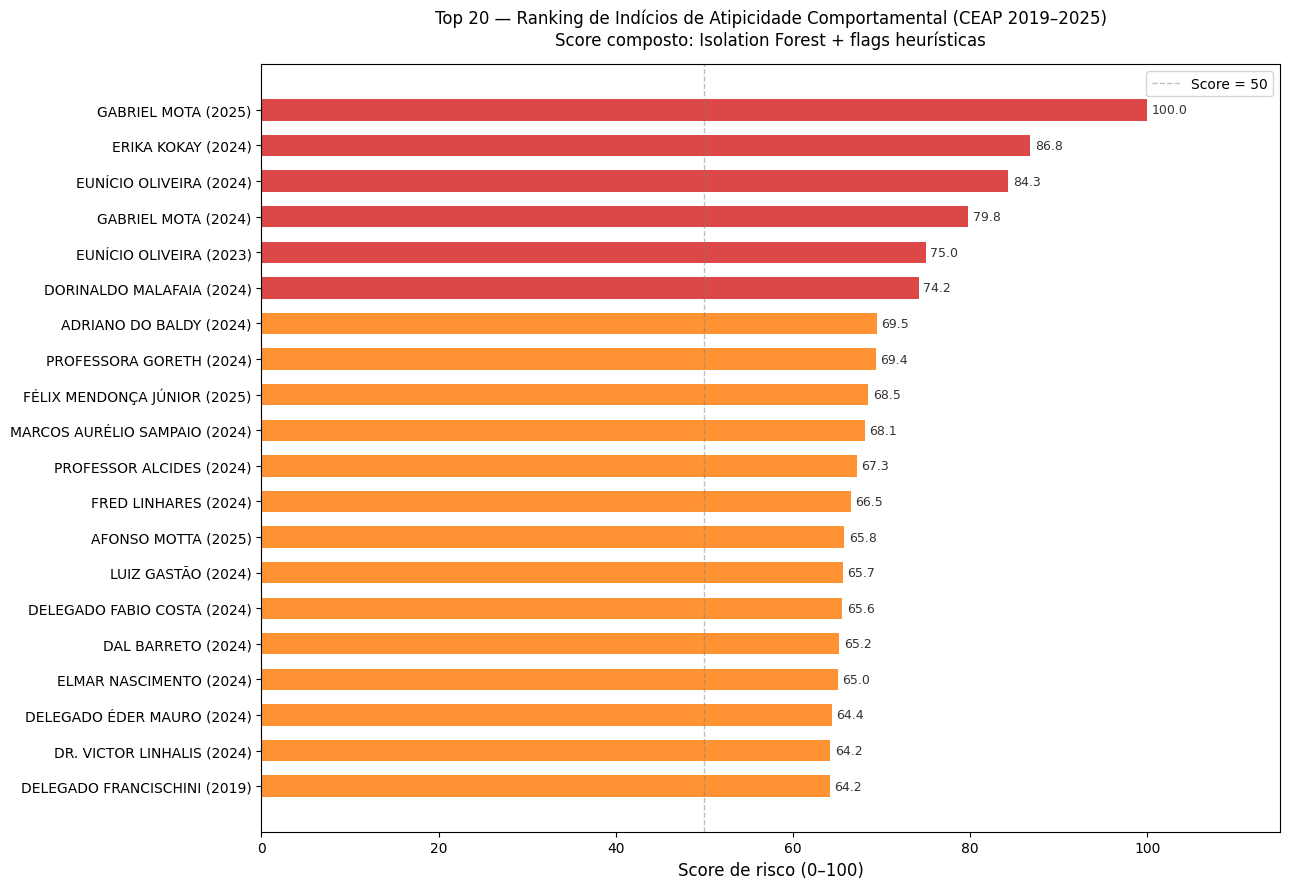

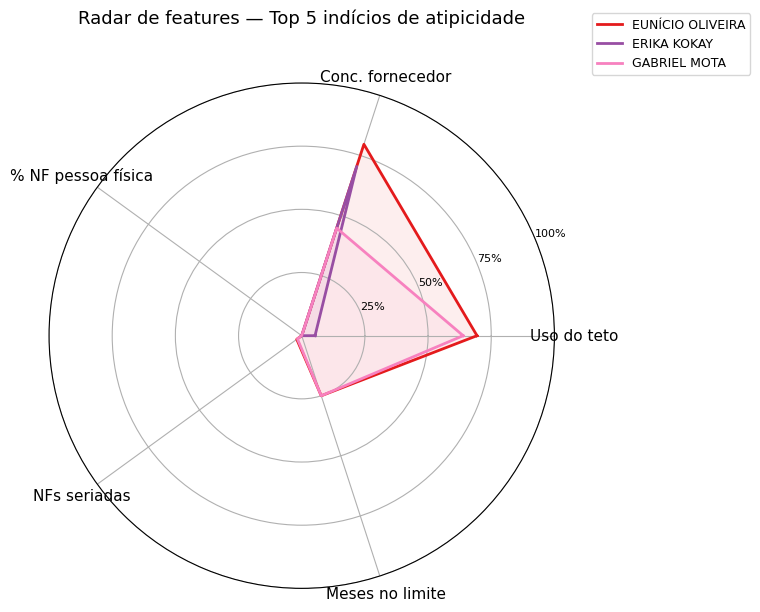

Outputs salvos em outputs/figures/ ✓


In [16]:
# BLOCO 12 — VISUALIZAÇÃO FINAL PARA RELATÓRIO (corrigido)

# Aplica correção de encoding nos nomes do ranking e do anual
ranking["nome_parlamentar"] = ranking["nome_parlamentar"].apply(corrigir_encoding)
anual["nome_parlamentar"]   = anual["nome_parlamentar"].apply(corrigir_encoding)

# Comparativo entre legislaturas
comp = (anual.groupby("periodo")
             .agg(
                 score_medio    = ("score_risco_final", "mean"),
                 pct_teto_medio = ("pct_teto_uso",      "mean"),
                 n_acima_teto   = ("flag_acima_teto",   "sum"),
                 n_conc_fornec  = ("flag_conc_fornecedor","sum"),
             )
             .reset_index())
print("Comparativo entre legislaturas:")
print(comp.to_string(index=False))

# Top 20 — gráfico de barras horizontais
top20 = ranking.head(20).copy().reset_index(drop=True)

# CORREÇÃO: constrói label elemento a elemento (não f-string na Serie)
top20["label"] = (
    top20["nome_parlamentar"].str[:22]
    + " ("
    + top20["ano"].astype(int).astype(str)   # int evita ".0"
    + ")"
)

cores = [
    "#d62728" if s >= 70 else "#ff7f0e" if s >= 50 else "#2ca02c"
    for s in top20["score_risco_final"]
]

fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(
    top20["label"][::-1],
    top20["score_risco_final"][::-1],
    color=cores[::-1],
    alpha=0.85,
    height=0.6,
)
ax.axvline(50, color="gray", ls="--", lw=1, alpha=.5, label="Score = 50")
ax.set_xlabel("Score de risco (0–100)", fontsize=12)
ax.set_title(
    "Top 20 — Ranking de Indícios de Atipicidade Comportamental (CEAP 2019–2025)\n"
    "Score composto: Isolation Forest + flags heurísticas",
    fontsize=12, pad=14,
)
ax.legend(fontsize=10)

# Rótulo de valor no fim de cada barra
for i, (val, lbl) in enumerate(
    zip(top20["score_risco_final"][::-1], top20["label"][::-1])
):
    ax.text(val + 0.5, i, f"{val:.1f}", va="center", fontsize=9, color="#333333")

ax.set_xlim(0, 115)
plt.tight_layout()
plt.savefig("outputs/figures/ranking_top20.png", dpi=150, bbox_inches="tight")
plt.show()

# Radar — top 5 outliers
RADAR_FEATURES = [
    "pct_teto_uso",
    "max_conc_fornecedor",
    "pct_pf",
    "n_nf_seriadas",
    "n_meses_limite_exato",
]
LABELS_RADAR = [
    "Uso do teto",
    "Conc. fornecedor",
    "% NF pessoa física",
    "NFs seriadas",
    "Meses no limite",
]

top5 = anual.loc[
    anual["nome_parlamentar"].isin(ranking.head(5)["nome_parlamentar"])
].drop_duplicates("nome_parlamentar").head(5)

# Normaliza para [0, 1] em relação ao dataset completo
normed = (
    (top5[RADAR_FEATURES] - anual[RADAR_FEATURES].min()) /
    (anual[RADAR_FEATURES].max() - anual[RADAR_FEATURES].min() + 1e-9)
).reset_index(drop=True)

N = len(RADAR_FEATURES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # fecha o polígono

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
colors = cm.Set1(np.linspace(0, 0.8, len(top5)))

for idx, (_, row) in enumerate(normed.iterrows()):
    valores = row.tolist() + row.tolist()[:1]
    nome    = top5.iloc[idx]["nome_parlamentar"][:20]
    ax.plot(angles, valores, color=colors[idx], linewidth=2, label=nome)
    ax.fill(angles, valores, color=colors[idx], alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(LABELS_RADAR, fontsize=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8)
ax.set_title(
    "Radar de features — Top 5 indícios de atipicidade",
    fontsize=13, y=1.1
)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig("outputs/figures/radar_top5_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

print("Outputs salvos em outputs/figures/ ✓")

# Resultados
Análise de Conformidade da CEAP

A análise dos dados brutos indica que uma parcela dos parlamentares apresenta gastos que ultrapassam de forma recorrente o teto regulamentar para suas unidades federativas.*Observa-se um padrão de repetição estatística, onde parlamentares que extrapolam o limite da Cota para Exercício da Atividade Parlamentar (CEAP) em um período tendem a repetir o comportamento nos anos subsequentes, sugerindo que a extrapolação possui caráter habitual.
Estes achados sugerem  indícios de uso intensivo da cota ao longo do tempo, especialmente entre o grupo destacado.


Evolução Temporal e Distribuição Geográfica

A evolução da mediana dos gastos mensais evidencia uma queda acentuada no final de 2022, coincidente com a transição de legislatura. Complementarmente, o mapeamento de calor por unidade federativa (2019-2025) mostra que os anos iniciais de cada legislatura apresentam menor volume de despesas, seguido por um aumento gradual e consistente nos anos posteriores. Esse comportamento indica padrões cíclicos, compatíveis com mudanças institucionais e operacionais.(evolução temporal, analise exploratória, até mediana)

Detecção de Anomalias

Para a identificação de comportamentos atípicos, foram empregados dois modelos principais:

•	*Isolation Forest:* Este algoritmo de *Machine Learning* foi utilizado para definir o *score* de risco individual. Através da redução de dimensionalidade (PCA), 10 variáveis distintas foram projetadas em duas componentes principais (pca_1 e pca_2) para facilitar a visualização de valores anômalos em um espaço bidimensional. No mapa de calor gerado, a intensidade da cor e o tamanho do ponto indicam o grau de anormalidade do parlamentar em relação aos seus pares.

•	DBSCAN *(Density-Based Spatial Clustering):* Utilizado como método complementar não baseado em aprendizado de máquina, este algoritmo identificou clusters de gastos. Ele classificou outliers como "ruídos" que não se integram a nenhum agrupamento denso, e permitiu destacar parlamentares com padrões de gastos isolados.

Composição do Score de Risco Ponderado

Para conferir robustez aos resultados, foi desenvolvido um *score* composto ponderado, que integra as detecções dos algoritmos com flags de risco específicas. A ponderação foi definida da seguinte forma:

| **Flag**               | **Ponderação** | **Descrição**                          |
|------------------------|----------------|-----------------------------------------|
| risco_iso              | 0,40           | Algoritmo Isolation Forest              |
| flag_acima_teto        | 0,15           | Acima do teto anual                     |
| flag_conc_fornecedor   | 0,15           | Concentração em único fornecedor        |
| flag_nf_seriadas       | 0,10           | Notas fiscais seriadas                  |
| flag_limite_exato      | 0,10           | Gasto exato no limite                   |
| flag_pf_alto           | 0,05           | Excesso de nota de PF                   |
| flag_dbscan_outlier    | 0,05           | Outliers do DBSCAN                      |

O modelo atribui maior relevância ao *Isolation Forest*, utilizando o DBSCAN como um validador complementar.

Resultados e Identificação de Casos Críticos

Após a normalização dos scores, foram identificados os 20 parlamentares que apresentam os indícios mais fortes de comportamento atípico. Para esses casos, foi gerado um gráfico de radar que sintetiza os principais indícios de irregularidade, permitindo uma visualização clara das dimensões onde a atipicidade é mais acentuada.

# Discussão

Ao analisar os histogramas de uso da Cota para Exercício da Atividade Parlamentar (CEAP) entre 2019 e 2025, os dados sugerem um padrão recorrente de utilização acima do teto regulamentar, especialmente com concentrações em torno de 150% do limite anual previsto para algumas unidades federativas. Essa recorrência indica que, na prática, parte dos parlamentares tende a operar próximos ou acima do valor permitido, o que caracteriza um comportamento sistemático relevante do ponto de vista analítico.

Esse comportamento indica que o teto da cota é constantemente interpretado como uma “sugestão orçamentária”, e não como um limite orçamentário rígido de conformidade. A repetição anual desses padrões sugere que exceder o limite foi incorporado à cultura administrativa, provavelmente devido a processos operacionais e administrativos consolidados e à ausência de sanções punitivas para gastos que excedem os 100% nominais.

O fato de o gráfico apresentar uma "explosão" de dados acima de 140% é um indicador direto de que os mecanismos de controle preventivo atuais não exercem pressão restritiva suficiente para manter as despesas dentro dos parâmetros regulamentares.

A análise temporal dos dados aponta para uma dinâmica de gastos influenciada pelo ciclo legislativo. A mediana mensal expõe um corte súbito ao final do ano de 2022, marcando a transição de legislatura, seguido por uma rápida retomada e aceleração nos anos subsequentes. Essa oscilação sugere uma "curva de aprendizado político": o aumento progressivo nos gastos pós-posse indica que parlamentares e seus gabinetes aprimoram a capacidade de consumo da cota ao longo do mandato. Geograficamente, o mapa de calor por Unidade Federativa confirma essa expansão gradual da mediana de gastos.

No âmbito das subcategorias, a predominância de despesas com "Divulgação da Atividade Parlamentar" (liderando isoladamente com mais de R$ 500 milhões) e "Passagens Aéreas" levanta um debate ético sobre a eficiência da alocação. A priorização de gastos com autopromoção em detrimento de categorias logísticas essenciais sugere um potencial desvio de finalidade, onde a verba pública passa a custear a manutenção de capital político-eleitoral.

A confiabilidade deste estudo foi sustentada por uma abordagem híbrida, utilizando o algoritmo *Isolation Forest* ao método DBSCAN. A aplicação de Componentes Principais (PCA) foi estratégica para reduzir a dimensionalidade dos dados e mitigar o ruído visual, permitindo isolar assinaturas comportamentais únicas que divergem da massa densa de transações consideradas "normais". A superioridade do modelo *Isolation Forest* no *score* composto (peso 0,4) justifica-se por sua aptidão em detectar anomalias em dados complexos que escapariam a uma análise humana convencional. Ao integrar flags heurísticas (como a concentração em fornecedores específicos (15%) e o uso de notas fiscais seriadas (10%)) o modelo transcende a estatística pura para se tornar uma ferramenta de compliance cívico. Essa estrutura permite distinguir com precisão o "*outlier* de valor" (quem gasta muito) do "*outlier* comportamental" (quem apresenta padrões lógicos suspeitos que simulam legalidade).

A interpretação dos perfis de risco elevados no "Top 20" exige uma análise pautada pela Responsabilidade Analítica. O Ranking de Indícios de Atipicidade Comportamental isolou casos emblemáticos através do *score* composto ponderado:

- Gabriel Mota (2025): Atingiu o escore máximo de 100.0, posicionando-se como o outlier mais distante da normalidade estatística em toda a base analisada.
- Erika Kokay (2024): Apresentou um escore de 86.8, figurando no topo do ranking devido a padrões de gastos que divergem da densidade esperada para o período.
- Eunício Oliveira (2024): Com um escore de 84.3, sua posição reforça a recorrência de um padrão de consumo exauriente e atípico da cota.

É importante enfatizar que esses resultados não constituem afirmações de irregularidade, mas sim indicam observações que se distanciam estatisticamente do padrão predominante e, portanto, podem ser priorizadas em auditorias humanas.

O modelo funciona como um filtro de priorização , ou como ferramenta de triagem algorítmica. Em vez de fiscais analisarem milhões de recibos aleatoriamente, os órgãos de controle podem focar seus esforços onde a probabilidade de erros e/ou fraudes é matematicamente maior, tornando a fiscalização mais eficiente.

Perspectivas para próximos estudos seria averiguar se os gastos são fisicamente possíveis, ou seja, se o parlamentar realmente estava no local da despesa. Além disso, é essencial checar se as empresas que recebem grandes valores existem de fato ou se são apenas 'empresas de fachada' usadas para desviar dinheiro público. Além disso, a validação cadastral e operacional dos fornecedores de maior volume pode fortalecer a identificação de possíveis inconsistências nos registros, ampliando a robustez metodológica da auditoria algorítmica



## Referências

AGGARWAL, Charu C. **Outlier Analysis**. 2. ed. Cham: Springer, 2017.  

BRASIL. Câmara dos Deputados. **Ato da Mesa n. 43, de 21 de maio de 2009**. Institui a Cota para o Exercício da Atividade Parlamentar. Brasília, DF: Câmara dos Deputados, 2009. Disponível em: <https://www2.camara.leg.br>. Acesso em: 6 abr. 2026.  

CHANDOLA, V.; BANERJEE, A.; KUMAR, V. Anomaly detection: A survey. **ACM Computing Surveys**, v. 41, n. 3, p. 1-58, 2009.  
DOI: https://doi.org/10.1145/1541880.1541882  

COSTA JUNIOR, L. P. **Operação Serenata de Amor: mediação, dados abertos e accountability para cidadania digital**. 2024. Dissertação (Mestrado em Comunicação) – Universidade Federal do Maranhão, São Luís, 2024.  

DAL POZZO, Flavio. **Operação Serenata de Amor: análise de um projeto de tecnologia cívica que usa inteligência artificial para auditar contas públicas**. 2020. Dissertação (Mestrado em Políticas Públicas) – Universidade Federal do Rio Grande do Sul, Porto Alegre, 2020. Disponível em: <http://hdl.handle.net/10183/215308>. Acesso em: 12 abr. 2026.  

FAYYAD, U.; PIATETSKY-SHAPIRO, G.; SMYTH, P. From Data Mining to Knowledge Discovery in Databases. **AI Magazine**, v. 17, n. 3, p. 37-54, 1996.  

HUPE, Peter; EDWARDS, Anne. Accountability and public governance. **Critical Policy Studies**, v. 6, n. 1, p. 1–20, 2012.  

LIU, Fei Tony; TING, Kai Ming; ZHOU, Zhi-Hua. **Isolation Forest**. In: *IEEE International Conference on Data Mining (ICDM)*, 2008, Pisa. Proceedings… Pisa: IEEE, 2008. p. 413–422.  
DOI: https://doi.org/10.1109/ICDM.2008.17  

O'DONNELL, G. Accountability horizontal e novas poliarquias. **Lua Nova: Revista de Cultura e Política**, São Paulo, n. 44, p. 27-54, 1998.  

OKFN BRASIL. **Serenata de Amor – GitHub Repository**. 2017. Disponível em: <https://github.com/okfn-brasil/serenata-de-amor>. Acesso em: 12 abr. 2026.  

PINHEIRO, R. *et al.* Identifying Anomalies in Parliamentary Expenditures of Brazilian Chamber of Deputies with Deep Autoencoders. In: **IEEE International Joint Conference on Neural Networks (IJCNN)**, 2017, Anchorage. *Proceedings…* Anchorage: IEEE, 2017. p. 3456–3463.  
DOI: https://doi.org/10.1109/IJCNN.2017.7966214  

SERENATA DE AMOR PROJECT. **Operação Serenata de Amor: Auditoria Algorítmica da Cota Parlamentar**. Brasília, 2017. Disponível em: <https://serenata.ai/>. Acesso em: 12 abr. 2026.



In [20]:
!quarto install tinytex --no-prompt

Installing tinytex
[✓] Downloading TinyTex v2026.04
[✓] Unzipping TinyTeX-v2026.04.tar.gz
[✓] Moving files
[✓] Verifying tlgpg support
[✓] Configuring font paths
[✓] Default Repository: https://ctan.math.washington.edu/tex-archive/systems/texlive/tlnet/
Installation successful


In [32]:
!quarto render relatorio_final_VF3.qmd --to pdf


Starting python3 kernel...Done

Executing 'relatorio_final_VF3.quarto_ipynb'
  Cell 1/13: 'setup'.................Done
  Cell 2/13: 'download'..............Done
  Cell 3/13: 'limpeza'...............Done
  Cell 4/13: 'teto-ceap'.............Done
  Cell 5/13: 'feature-engineering'...Done
  Cell 6/13: 'vetor-features'........Done
  Cell 7/13: 'top10-por-ano'.........Done
  Cell 8/13: 'eda'...................Done
  Cell 9/13: 'isolation-forest'......Done
  Cell 10/13: 'dbscan'................Done
  Cell 11/13: 'score-risco'...........Done
  Cell 12/13: 'validacao'.............Done
  Cell 13/13: 'visualizacao-final'....Done

pandoc 
  to: latex
  output-file: relatorio_final_VF3.tex
  standalone: true
  pdf-engine: xelatex
  variables:
    graphics: true
    tables: true
  default-image-extension: pdf
  toc: false
  number-sections: true
  
metadata
  documentclass: scrartcl
  classoption:
    - DIV=11
    - numbers=noendperiod
  papersize: a4
  header-includes:
    - '\KOMAoption{captions

In [33]:
from google.colab import files
files.download("relatorio_final_VF3.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>